# Heart Disease — Exploratory Data Analysis
Dataset: UCI Heart Disease (Cleveland), 14 attributes.
Goal: understand the data before cleaning or modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the dataset
Column names: age, sex, cp, trestbps, chol, fbs, restecg,
thalach, exang, oldpeak, slope, ca, thal, target.

If your downloaded CSV already has these headers, the first
line below is enough. If it came from the raw UCI `.data`
file with no headers, use the commented-out version instead.

In [2]:
df = pd.read_csv("../../data/raw/heart_disease.csv")

# If your file has no headers, use this instead:
# columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
#            "exang","oldpeak","slope","ca","thal","target"]
# df = pd.read_csv("../../data/raw/heart_disease.csv", names=columns)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Basic info

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Check for missing / invalid values
The UCI heart disease data sometimes marks missing values
in `ca` and `thal` as `?` (loaded as a string) instead of NaN.

In [6]:
for col in df.columns:
    n_missing = df[col].isnull().sum()
    n_question_mark = (df[col].astype(str) == "?").sum()
    if n_missing or n_question_mark:
        print(f"{col}: {n_missing} NaN, {n_question_mark} '?' values")


## 4. Class balance
`target`: 1 = heart disease present, 0 = no heart disease
(some versions use 0-4 severity — check your file and
binarize if needed: `df['target'] = (df['target'] > 0).astype(int)`)

target
1    165
0    138
Name: count, dtype: int64


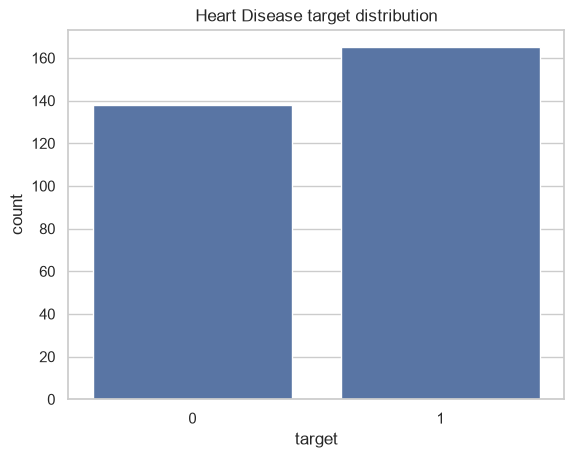

In [7]:
print(df["target"].value_counts())

sns.countplot(x="target", data=df)
plt.title("Heart Disease target distribution")
plt.show()


## 5. Feature distributions

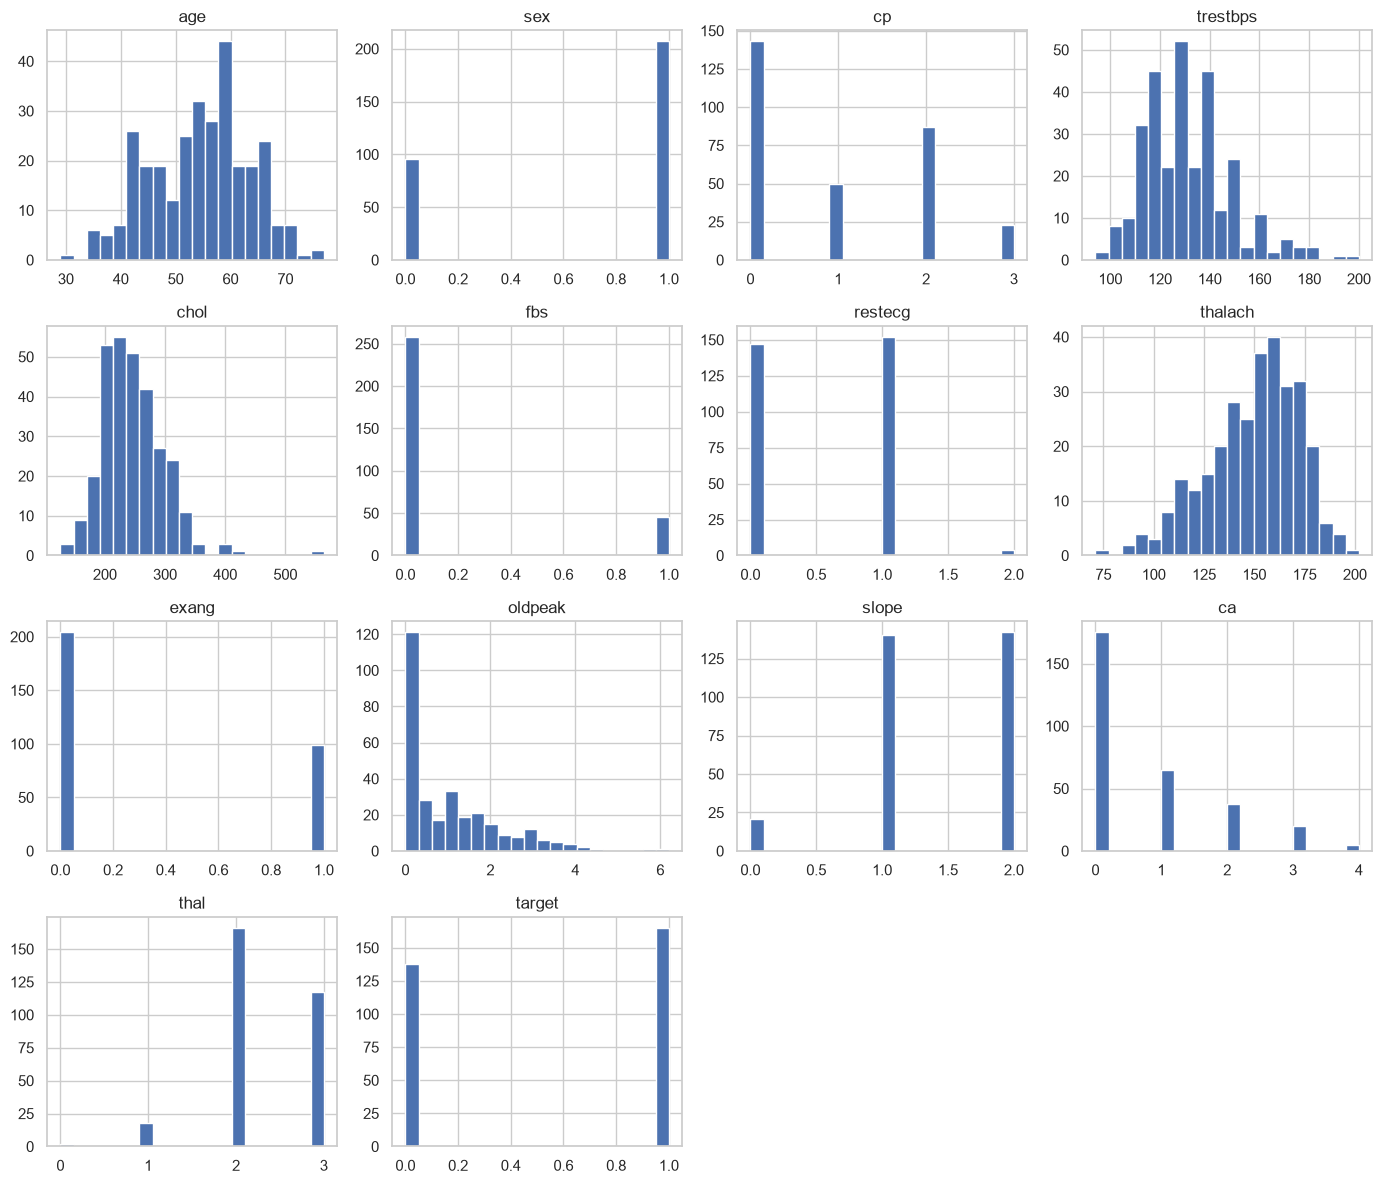

In [8]:
df.hist(figsize=(14, 12), bins=20)
plt.tight_layout()
plt.show()


## 6. Correlation heatmap

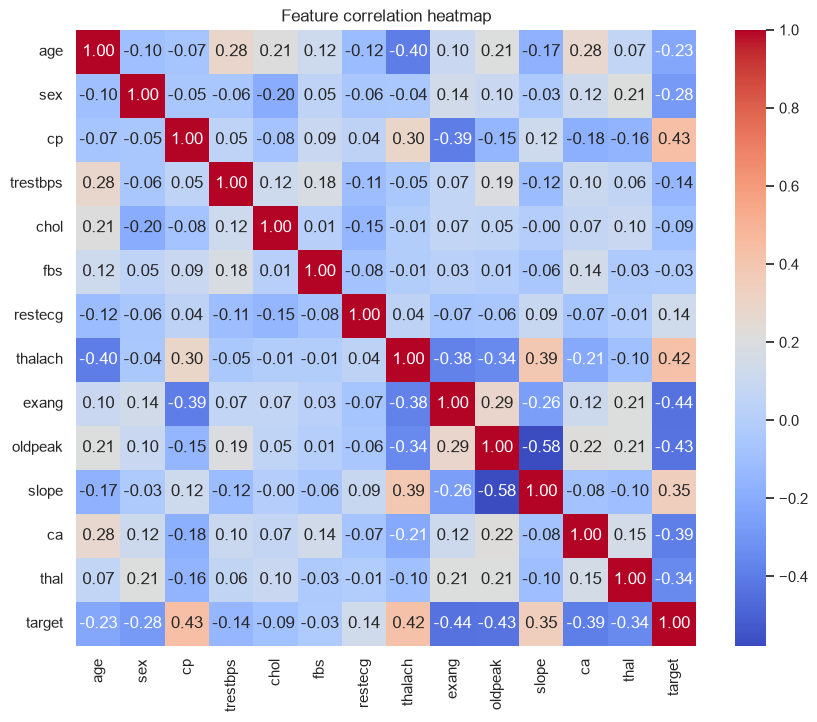

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


## 7. Key features by target
Max heart rate (thalach) and cholesterol are commonly
predictive — let's check visually.

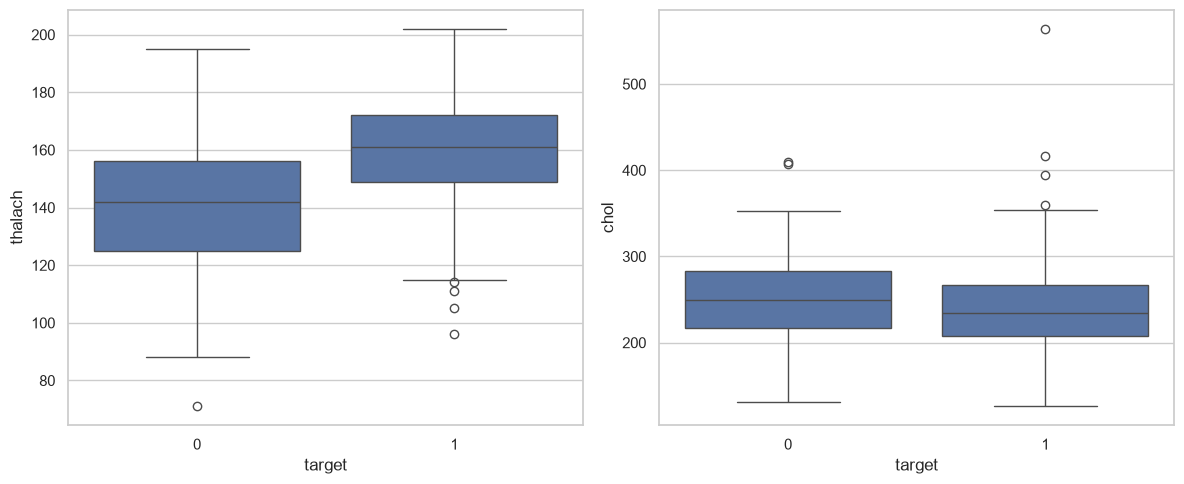

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="target", y="thalach", data=df, ax=axes[0])
sns.boxplot(x="target", y="chol", data=df, ax=axes[1])
plt.tight_layout()
plt.show()


## Notes / takeaways
_Write down what you notice here before moving to preprocessing._